In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [7]:
data=pd.read_excel("data/reglarite-mensuelle-tgv-nationale.xlsx")
data.head(10)

,Date,Régularité composite,Ponctualité origine
0,2015-01,91.627358,85.280538
1,2015-02,90.325652,84.248184
2,2015-03,93.421794,87.453249
3,2015-04,90.801173,85.342175
4,2015-05,91.373510,85.048795
5,2015-06,87.697086,82.612883
6,2015-07,84.887154,79.819406
7,2015-08,89.102128,82.234832
8,2015-09,89.545803,84.638101
9,2015-10,91.013911,85.124313


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  138 non-null    str    
 1   Régularité composite  138 non-null    float64
 2   Ponctualité origine   138 non-null    float64
dtypes: float64(2), str(1)
memory usage: 3.4 KB


In [9]:
data.isna().sum()

Date                    0
Régularité composite    0
Ponctualité origine     0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m')
data['Annee'] = data['Date'].dt.year
data['Mois'] = data['Date'].dt.month

In [12]:
data.head(20)

,Date,Régularité composite,Ponctualité origine,Annee,Mois
0,2015-01-01,91.627358,85.280538,2015,1
1,2015-02-01,90.325652,84.248184,2015,2
2,2015-03-01,93.421794,87.453249,2015,3
3,2015-04-01,90.801173,85.342175,2015,4
4,2015-05-01,91.373510,85.048795,2015,5
5,2015-06-01,87.697086,82.612883,2015,6
6,2015-07-01,84.887154,79.819406,2015,7
7,2015-08-01,89.102128,82.234832,2015,8
8,2015-09-01,89.545803,84.638101,2015,9
9,2015-10-01,91.013911,85.124313,2015,10


In [13]:
data["Annee"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026], dtype=int32)

In [14]:
variables_descr=["Régularité composite", "Ponctualité origine"]
data[variables_descr].describe()

,Régularité composite,Ponctualité origine
count,138.000000,138.000000
mean,88.685763,83.137958
std,2.931835,3.376082
min,77.851061,72.269528
25%,87.000754,81.296658
50%,89.075756,83.413237
75%,90.743996,85.266584
max,94.559508,90.732140


Première description:

Notre dataset provient de l'open Data de la SNCF. Il comporte **138** observations sur **3** variables qui sont:
- "Régularité composite": elle correspond au pourcentage de trains arrivés à l'heure à leur gare de destination. Elle est mesurée à la gare d'arrivée. 
- "Ponctualité origine" : elle correspond au pourcentage de trains qui partent à l'heure. Elle est mesurée à la gare de départ.
- "Date": correspond au mois et année d'observation. Le dataset couvre la période de janvier 2015 à juin 2026.

Si on regarde un peu les statistiques, on peut voir qu'on a entre 72% et 90.73% des trains qui partent à l'heure et 77% à 94.56%  des trains arrivent à l'heure à destination.
En moyenne 88.69% des trains arrivent à l'heure et 83.14% des trains partent à l'heure.

Le dernier point est que le dataset ne comporte pas de valeurs manquantes ni de doublons.

NB: La notion de "arrivée à l'heure" n'est pas prise au sens strict des termes. Elle signifie plutôt "arrivée dans un délai jugé acceptable selon la durée du trajet (5, 10, 15 min de tolérance).

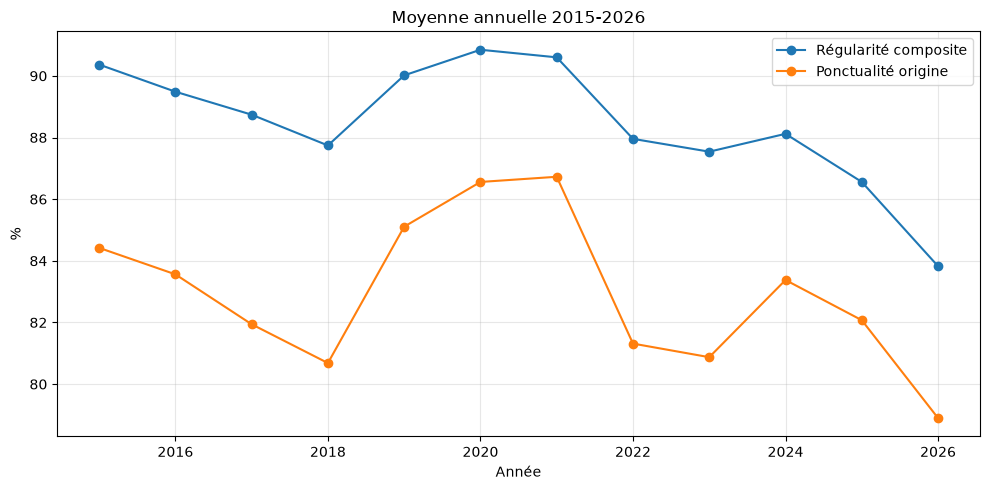

In [15]:
data_annee = data.groupby('Annee')[['Régularité composite', 'Ponctualité origine']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(data_annee['Annee'], data_annee['Régularité composite'], marker='o', label='Régularité composite')
plt.plot(data_annee['Annee'], data_annee['Ponctualité origine'], marker='o', label='Ponctualité origine')

plt.title('Moyenne annuelle 2015-2026')
plt.xlabel('Année')
plt.ylabel('%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

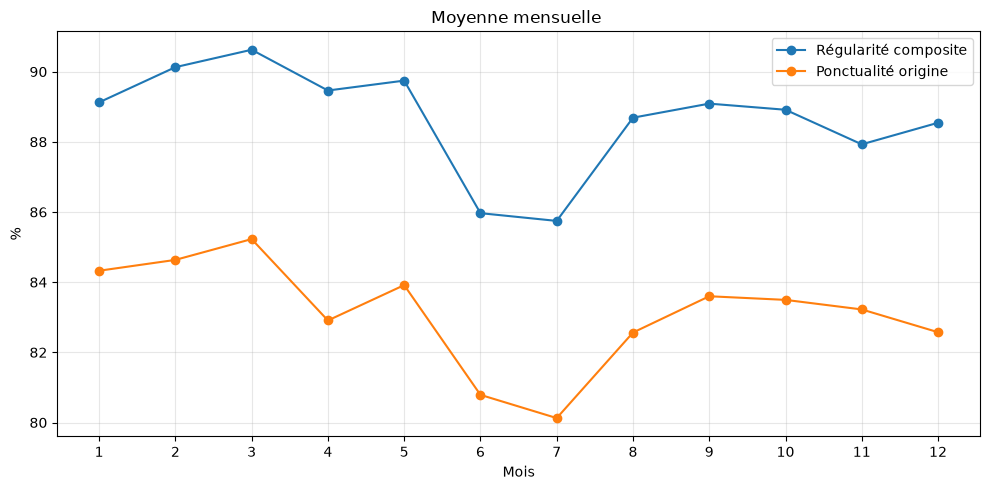

In [16]:
data_mois = data.groupby('Mois')[['Régularité composite', 'Ponctualité origine']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(data_mois['Mois'], data_mois['Régularité composite'], marker='o', label='Régularité composite')
plt.plot(data_mois['Mois'], data_mois['Ponctualité origine'], marker='o', label='Ponctualité origine')

plt.title('Moyenne mensuelle ')
plt.xlabel('Mois')
plt.ylabel('%')
plt.xticks(range(1, 13))  # affiche 1 à 12 sur l'axe X, pas de valeurs décimales
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analyse des graphiques**

- Le graphique par année révèle une évolution en trois phases plutôt qu'une tendance linéaire.

De 2015 à 2018, la régularité baisse, avec un creux en 2018 (87,74%). Entre 2019 et 2021, elle remonte nettement pour atteindre son point 
haut en 2020 (90,85%), avant de rechuter dès 2022 (87,96%) et de continuer à se dégrader jusqu'en 2026 (83,83% sur les 6 premiers mois).

Le pic observé en 2020-2021 ne traduit pas une amélioration opérationnelle de la SNCF : il coïncide avec la pandémie de Covid-19 et la forte baisse du trafic ferroviaire durant 
cette période. Moins de circulations signifie mécaniquement moins de risques de retard et de correspondances perturbées, indépendamment de tout effort d'amélioration du réseau. 
Ce pic est donc un artefact de contexte, à ne pas interpréter comme une tendance de fond.

- Le graphique par mois fait apparaître un schéma saisonnier récurrent : juin et juillet sont systématiquement les mois les moins 
performants, tandis que mars ressort comme le meilleur mois.

Cette baisse estivale est cohérente avec deux phénomènes structurels du réseau ferroviaire : la période de travaux d'été (maintenance des voies, souvent programmée 
hors saison hivernale) et le pic de trafic voyageurs lié aux départs en vacances, qui sature davantage le réseau et augmente le risque de retards en cascade.



In [17]:
data=pd.read_csv("data/regularite-mensuelle-tgv-aqst.csv",sep=";")
data.head(10)

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386
5,2018-01,National,ST MALO,PARIS MONTPARNASSE,158,92,0,NaN,2,1.225000,...,6,4.763978,3,1,22.222222,66.666667,0.000000,11.111111,0.000000,0.000000
6,2018-01,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,184,0,NaN,23,11.221739,...,26,7.510507,12,3,59.090909,22.727273,4.545455,9.090909,4.545455,0.000000
7,2018-01,National,VANNES,PARIS MONTPARNASSE,156,278,1,NaN,168,5.120437,...,25,6.241487,11,3,24.137931,44.827586,20.689655,3.448276,3.448276,3.448276
8,2018-01,National,REIMS,PARIS EST,46,230,1,NaN,93,7.432796,...,20,3.538937,3,0,17.948718,41.025641,20.512821,5.128205,0.000000,15.384615
9,2018-01,National,DOUAI,PARIS NORD,77,197,3,NaN,39,8.032906,...,10,5.046907,5,3,36.363636,18.181818,22.727273,18.181818,4.545455,0.000000


In [18]:
print(data.columns.tolist())

['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, corre

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int64  
 5   Nombre de circulations prévues             

In [20]:
print(data["Date"].min(), data["Date"].max())

2018-01 2026-06


**Premier regard sur le dataset**

Notre dataset détaille, pour chaque liaison TGV et chaque mois entre Janvier 2018 et Juin 2026, les volumes des circulations, retards et annulations, ainsi que la répartition des causes de retard.
Il comporte 12544 observations décrites sur 26 colonnes.
On peut scinder en différentes catégories les colonnes présentes.
On a le tableau suivant:
### Catégorisation des variables

| Catégorie | Variables | Description |
|---|---|---|
| **Identification** | `Date`, `Service`, `Gare de départ`, `Gare d'arrivée`, `Durée moyenne du trajet` | Décrivent le contexte de chaque observation : quelle liaison, à quel mois, quel type de service, et la durée du trajet |
| **Volumes** | `Nombre de circulations prévues`, `Nombre de trains annulés`, `Nombre de trains en retard au départ`, `Nombre de trains en retard à l'arrivée`, `Nombre trains en retard > 15min`, `Nombre trains en retard > 30min`, `Nombre trains en retard > 60min` | Comptages bruts de trains (circulations, annulations, retards par palier de sévérité) |
| **Retards (minutes)** | `Retard moyen des trains en retard au départ`, `Retard moyen de tous les trains au départ`, `Retard moyen des trains en retard à l'arrivée`, `Retard moyen de tous les trains à l'arrivée`, `Retard moyen trains en retard > 15 (si liaison concurrencée par vol)` | Durées moyennes de retard, à distinguer selon qu'elles sont calculées sur les seuls trains en retard ou sur l'ensemble des trains |
| **Causes de retard (%)** | `Prct retard pour causes externes`, `Prct retard pour cause infrastructure`, `Prct retard pour cause gestion trafic`, `Prct retard pour cause matériel roulant`, `Prct retard pour cause gestion en gare et réutilisation de matériel`, `Prct retard pour cause prise en compte voyageurs` | Répartition en pourcentage des causes structurelles de retard |
| **Commentaires** | `Commentaire annulations`, `Commentaire retards au départ`, `Commentaire retards à l'arrivée` | Texte libre décrivant ponctuellement des incidents marquants |

Avant de continuer regardons de près les colonnes "commentaires"

In [21]:
data["Commentaire annulations"].unique()

array([nan])

In [22]:
data["Commentaire retards au départ"].unique()

array([nan])

In [23]:
data["Commentaire retards à l'arrivée"].nunique()

302

In [24]:
data["Commentaire retards à l'arrivée"].isna().mean()*100

np.float64(94.43558673469387)

**Les commentaires concernant les annulations et les retards au départ sont vides. Ils n'apportent aucune information. On peut les supprimer définitivement**
**Par contre, les commentaires concernant les retards à l'arrivé ne sont pas vides. Environ 5.5% ont été renseignés**
**On ne les utilisera pas pour notre modèle car statistiquement negligeable mais ils pourront servir d'interprétations des résultas**

In [25]:
colonnes_comm=["Commentaire annulations", "Commentaire retards au départ","Commentaire retards à l'arrivée"]
data=data.drop(columns=colonnes_comm)

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 23 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int64  
 5   Nombre de circulations prévues             

**Les colonnes ont été supprimées. Les colonnes restantes sont toutes de types numériques et object.**

**On peut regarder maintenant l'existence des données: manquantes, doublons, erreurs, etcc**

In [27]:
valeurs_manquantes = ["", " ", "NA", "N/A", "na", "n/a", "NULL", "null", "None", "none", "-",]

missing = (data.isna() | data.map(lambda x: isinstance(x, str) and x.strip() in valeurs_manquantes))

print("Valeurs manquantes :", missing.sum().sum())

Valeurs manquantes : 0


In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
data.describe()

,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
count,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000
mean,170.628508,272.623884,8.407685,86.219866,12.499854,3.175135,38.243304,35.471909,6.196906,27.576531,36.739460,13.025989,5.370615,21.897002,21.491158,20.118126,18.993447,7.762730,7.581653
std,87.730733,183.559230,22.089205,88.428503,11.660090,5.054562,31.826539,15.605191,6.930326,23.316212,19.388035,12.684545,6.250032,16.068989,14.914196,14.709970,13.564449,8.682545,9.451102
min,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-472.638889,0.000000,-4.000000,-44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,99.000000,151.000000,0.000000,22.000000,6.346596,1.226076,16.000000,25.958062,3.454553,11.000000,28.732917,4.000000,1.000000,10.714286,11.538462,10.000000,10.000000,0.000000,0.000000
50%,163.000000,230.000000,2.000000,52.000000,10.560933,2.368000,30.000000,33.777423,5.452094,22.000000,38.004578,10.000000,3.000000,19.642857,20.000000,18.461538,17.142857,5.882353,5.031800
75%,223.000000,362.000000,7.000000,126.000000,16.101225,4.031985,52.000000,42.776681,8.249353,37.000000,47.501389,18.000000,7.000000,30.252101,29.268293,28.571429,25.617573,11.398558,11.111111
max,786.000000,1100.000000,297.000000,596.000000,316.188095,115.047390,376.000000,299.600000,92.000000,312.000000,299.600000,202.000000,77.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Variables à regarder:
- Nombre de trains en retard > 30 min
- Retard moyen trains en retard > 15 (si liaison concurrencée par vol)
- Retard moyen de tous les trains à l'arrivée
- Retard moyen des trains en retard à l'arrivée
- Retard moyen de tous les trains au départ

**A présent, on peut regarder les anomales dans les variables**

In [30]:
#variable Date
data["Date"]=pd.to_datetime(data["Date"])
data["Mois"]=data["Date"].dt.month
data["Année"]=data["Date"].dt.year
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 25 columns):
 #   Column                                                                                       Non-Null Count  Dtype         
---  ------                                                                                       --------------  -----         
 0   Date                                                                                         12544 non-null  datetime64[us]
 1   Service                                                                                      12544 non-null  str           
 2   Gare de départ                                                                               12544 non-null  str           
 3   Gare d'arrivée                                                                               12544 non-null  str           
 4   Durée moyenne du trajet                                                                      12544 non-null  int64         

In [31]:
colonnes_retard=["Nombre trains en retard > 30min",
                "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
                "Retard moyen de tous les trains à l'arrivée",
                "Retard moyen des trains en retard à l'arrivée",
                "Retard moyen de tous les trains au départ"]



In [32]:
(data[colonnes_retard] < 0).sum()

Nombre trains en retard > 30min                                          43
Retard moyen trains en retard > 15 (si liaison concurrencée par vol)      8
Retard moyen de tous les trains à l'arrivée                             121
Retard moyen des trains en retard à l'arrivée                             2
Retard moyen de tous les trains au départ                               170
dtype: int64

In [33]:
#nombre de trains en retard de plus de 30min
data.loc[
    data["Nombre trains en retard > 30min"] < 0,
    ["Date", "Nombre trains en retard > 30min","Service","Gare de départ","Gare d'arrivée"]]

,Date,Nombre trains en retard > 30min,Service,Gare de départ,Gare d'arrivée
10326,2025-01-01,-4,International,LAUSANNE,PARIS LYON
10329,2025-01-01,-1,National,DIJON VILLE,PARIS LYON
10330,2025-01-01,-1,National,DOUAI,PARIS NORD
10357,2025-01-01,-1,National,LE MANS,PARIS MONTPARNASSE
10358,2025-01-01,-2,National,MARSEILLE ST CHARLES,MARNE LA VALLEE
10379,2025-01-01,-1,National,LILLE,PARIS NORD
10380,2025-01-01,-44,National,LYON PART DIEU,LILLE
10381,2025-01-01,-2,National,LYON PART DIEU,MARNE LA VALLEE
10382,2025-01-01,-3,National,LYON PART DIEU,PARIS LYON
10392,2025-01-01,-1,National,QUIMPER,PARIS MONTPARNASSE


In [34]:
cols = [
    "Nombre trains en retard > 30min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains au départ"
]

data.loc[data["Nombre trains en retard > 30min"] < 0, cols]

,Nombre trains en retard > 30min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Retard moyen de tous les trains à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains au départ
10326,-4,43.332222,4.154424,43.332222,1.512140
10329,-1,52.390071,6.394747,43.926111,5.465877
10330,-1,37.257143,6.972828,23.273643,3.517475
10357,-1,54.700000,7.451927,28.586721,7.116774
10358,-2,34.370930,7.560980,34.370930,1.046847
10379,-1,32.261905,4.399478,18.259662,1.914345
10380,-44,32.144271,9.078078,28.748699,6.324621
10381,-2,33.956746,6.517269,25.760952,6.267685
10382,-3,43.481395,3.389963,33.585156,2.886283
10392,-1,46.640860,6.759852,46.640860,0.510121


**concernant le nombre de trains, à ce stade, nous ne savons pas d'où viennent ces valeurs négatives. On peut les supprimer (0.34%)? ou on les garde?**